=== BB84 Protocol Simulation ===
Total qubits sent: 200
Intercept probability: 30%
Sifted key length: 102 bits
Error rate: 8.82%

Alice's sifted key:  010010000100101110111100011011011101010111111101111011101010001100001100010000001101010011100101001100
Bob's sifted key:    010000100000101110111000011001011101010111111101011011101010001100011100010010101101010011100101001100


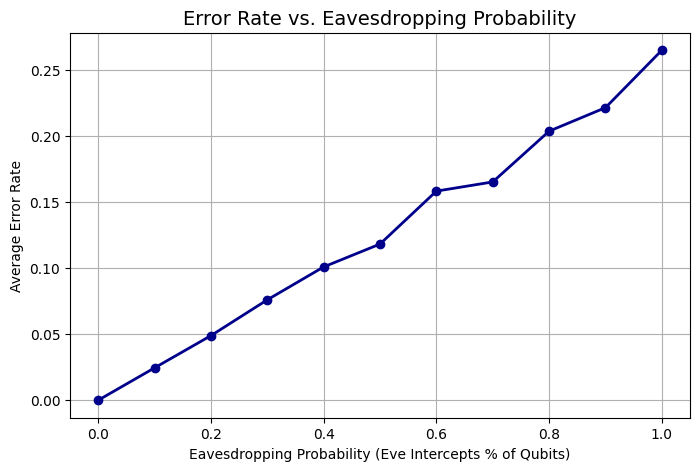

In [ ]:
# ==========================================================
# Quantum Key Distribution (BB84 Protocol) — Simulation
# Author: [Your Name]
# ==========================================================
# This simulation models the BB84 protocol using classical logic.
# It shows how Alice and Bob can share a secure key, and how
# an eavesdropper (Eve) introduces detectable errors.
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. Define helper functions
# -----------------------------

def generate_random_bits(n):
    """Generate n random bits (0 or 1)."""
    return np.random.randint(0, 2, n)

def generate_random_bases(n):
    """Generate n random bases (0 = rectilinear, 1 = diagonal)."""
    return np.random.randint(0, 2, n)

def encode_qubits(bits, bases):
    """
    Encode bits as qubits according to chosen bases.
    Represented as tuples: (bit, basis)
    """
    return list(zip(bits, bases))

def measure_qubit(qubit, measurement_basis):
    """
    Measure a qubit in a given basis.
    If bases match, we get the same bit.
    If not, the result is random (simulating quantum uncertainty).
    """
    bit, prep_basis = qubit
    if prep_basis == measurement_basis:
        return bit
    else:
        # 50% chance of flipping if measured in the wrong basis
        return np.random.randint(0, 2)

def simulate_eve_interception(qubits, intercept_prob=0.2):
    """
    Simulate Eve intercepting a fraction of qubits.
    She measures each intercepted qubit in a random basis,
    then resends it to Bob. This introduces detectable errors.
    """
    n = len(qubits)
    eve_bases = generate_random_bases(n)
    attacked = np.random.rand(n) < intercept_prob
    new_qubits = []

    for i in range(n):
        if attacked[i]:
            # Eve measures in her random basis
            measured_bit = measure_qubit(qubits[i], eve_bases[i])
            # She resends it based on her measurement (possible disturbance)
            new_qubits.append((measured_bit, eve_bases[i]))
        else:
            # Qubit goes untouched
            new_qubits.append(qubits[i])

    return new_qubits, attacked

def sift_keys(bits_a, bases_a, bits_b, bases_b):
    """Keep only bits where Alice and Bob used the same basis."""
    mask = bases_a == bases_b
    return bits_a[mask], bits_b[mask]

# -----------------------------
# 2. Run the BB84 simulation
# -----------------------------

np.random.seed(42)  # for reproducibility
N = 200  # number of qubits

# Step 1: Alice's preparation
alice_bits = generate_random_bits(N)
alice_bases = generate_random_bases(N)
qubits = encode_qubits(alice_bits, alice_bases)

# Step 2: Eve intercepts some qubits
intercept_prob = 0.3
qubits_after_eve, eve_attacks = simulate_eve_interception(qubits, intercept_prob)

# Step 3: Bob measures
bob_bases = generate_random_bases(N)
bob_results = np.array([measure_qubit(q, b) for q, b in zip(qubits_after_eve, bob_bases)])

# Step 4: Public basis comparison (key sifting)
alice_key, bob_key = sift_keys(alice_bits, alice_bases, bob_results, bob_bases)

# Step 5: Compute error rate
errors = np.sum(alice_key != bob_key)
error_rate = errors / len(alice_key)

# -----------------------------
# 3. Print results
# -----------------------------

print("=== BB84 Protocol Simulation ===")
print(f"Total qubits sent: {N}")
print(f"Intercept probability: {intercept_prob*100:.0f}%")
print(f"Sifted key length: {len(alice_key)} bits")
print(f"Error rate: {error_rate*100:.2f}%\n")

print("Alice's sifted key: ", ''.join(map(str, alice_key)))
print("Bob's sifted key:   ", ''.join(map(str, bob_key)))

# -----------------------------
# 4. Analyze Eve’s effect
# -----------------------------

def analyze_eavesdropping_effect(N=200, trials=30):
    """
    Run BB84 multiple times for different intercept probabilities
    and plot the resulting error rate.
    """
    probs = np.linspace(0, 1, 11)
    avg_errors = []

    for p in probs:
        err_sum = 0
        for _ in range(trials):
            alice_bits = generate_random_bits(N)
            alice_bases = generate_random_bases(N)
            qubits = encode_qubits(alice_bits, alice_bases)

            qubits_after_eve, _ = simulate_eve_interception(qubits, p)
            bob_bases = generate_random_bases(N)
            bob_results = np.array([measure_qubit(q, b) for q, b in zip(qubits_after_eve, bob_bases)])
            alice_key, bob_key = sift_keys(alice_bits, alice_bases, bob_results, bob_bases)

            if len(alice_key) > 0:
                err_sum += np.sum(alice_key != bob_key) / len(alice_key)
        avg_errors.append(err_sum / trials)

    return probs, avg_errors

probs, avg_errors = analyze_eavesdropping_effect()

# -----------------------------
# 5. Plot results
# -----------------------------

plt.figure(figsize=(8, 5))
plt.plot(probs, avg_errors, 'o-', color='darkblue', linewidth=2)
plt.title("Error Rate vs. Eavesdropping Probability", fontsize=14)
plt.xlabel("Eavesdropping Probability (Eve Intercepts % of Qubits)")
plt.ylabel("Average Error Rate")
plt.grid(True)
plt.show()
